# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Global Tech AI Startups Dataset](https://www.kaggle.com/datasets/saitejabandaruin/automated-pipeline-dataset-output)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('global_tech_startups_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


## last Five row

In [4]:
df.tail()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
24995,00571113,SpaceTech,2020,USA,Austin,Series B,21.00,86.55,3.96,1.20,16.2,111,43,68,Tier 3 (Angel/Seed),High,Independent
24996,AFA8F35C,Cybersecurity,2017,UK,Oxford,Series B,29.38,316.21,16.36,3.11,9.2,214,99,115,Tier 2 (Mid-size VC),High,Independent
24997,0EEEA516,Web3/Crypto,2021,Singapore,Singapore,Series B,7.84,57.81,3.79,0.31,19.1,29,0,29,Tier 3 (Angel/Seed),High,Independent
24998,586B1BAF,ClimateTech,2020,Singapore,Singapore,Series A,0.00,33.67,1.96,0.45,0.0,41,0,41,Bootstrapped,High,Independent
24999,DC703A98,Web3/Crypto,2022,USA,Boston,Series A,6.15,70.04,3.96,0.65,8.2,40,29,11,Tier 3 (Angel/Seed),High,Closed


## Shape of our dataset

In [5]:
df.shape

(25000, 17)

## List out all columns

In [6]:
df.columns

Index(['Company_ID', 'Domain', 'Founding_Year', 'Country', 'City',
       'Funding_Stage', 'Total_Funding_USD_Millions', 'Valuation_USD_Millions',
       'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions',
       'Runway_Months_2024', 'Peak_Headcount_2023', 'Layoffs_2024_2025',
       'Current_Headcount_2026', 'Investor_Tier', 'AI_Adoption_Level',
       'Acquisition_Status'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Company_ID                     object
Domain                         object
Founding_Year                   int64
Country                        object
City                           object
Funding_Stage                  object
Total_Funding_USD_Millions    float64
Valuation_USD_Millions        float64
Revenue_ARR_Millions          float64
Monthly_Burn_Rate_Millions    float64
Runway_Months_2024            float64
Peak_Headcount_2023             int64
Layoffs_2024_2025               int64
Current_Headcount_2026          int64
Investor_Tier                  object
AI_Adoption_Level              object
Acquisition_Status             object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  object 
 1   Domain                      25000 non-null  object 
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  object 
 4   City                        25000 non-null  object 
 5   Funding_Stage               25000 non-null  object 
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      250

## Check Null Value

In [9]:
df.isnull().sum()

Company_ID                       0
Domain                           0
Founding_Year                    0
Country                          0
City                             0
Funding_Stage                    0
Total_Funding_USD_Millions       0
Valuation_USD_Millions           0
Revenue_ARR_Millions             0
Monthly_Burn_Rate_Millions       0
Runway_Months_2024               0
Peak_Headcount_2023              0
Layoffs_2024_2025                0
Current_Headcount_2026           0
Investor_Tier                    0
AI_Adoption_Level             2592
Acquisition_Status               0
dtype: int64

## Drop Null Features

In [10]:
df.drop(columns=['AI_Adoption_Level'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Founding_Year,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,2018.917400,59.631098,464.100121,33.300890,3.168847,12.189032,211.739920,31.563320,180.176600
std,2.811963,208.725699,1777.909318,139.243809,10.877553,10.099990,693.946443,175.987811,606.174385
min,2012.000000,0.000000,1.030000,0.050000,0.060000,0.000000,5.000000,0.000000,0.000000
25%,2017.000000,2.050000,28.997500,1.800000,0.430000,3.900000,30.000000,0.000000,22.000000
50%,2019.000000,8.465000,71.775000,4.825000,0.720000,10.600000,48.000000,0.000000,42.000000
75%,2021.000000,36.100000,267.795000,17.972500,2.240000,17.500000,154.000000,16.000000,119.000000
max,2025.000000,7867.390000,91692.420000,9021.530000,515.760000,89.600000,30086.000000,10280.000000,25657.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

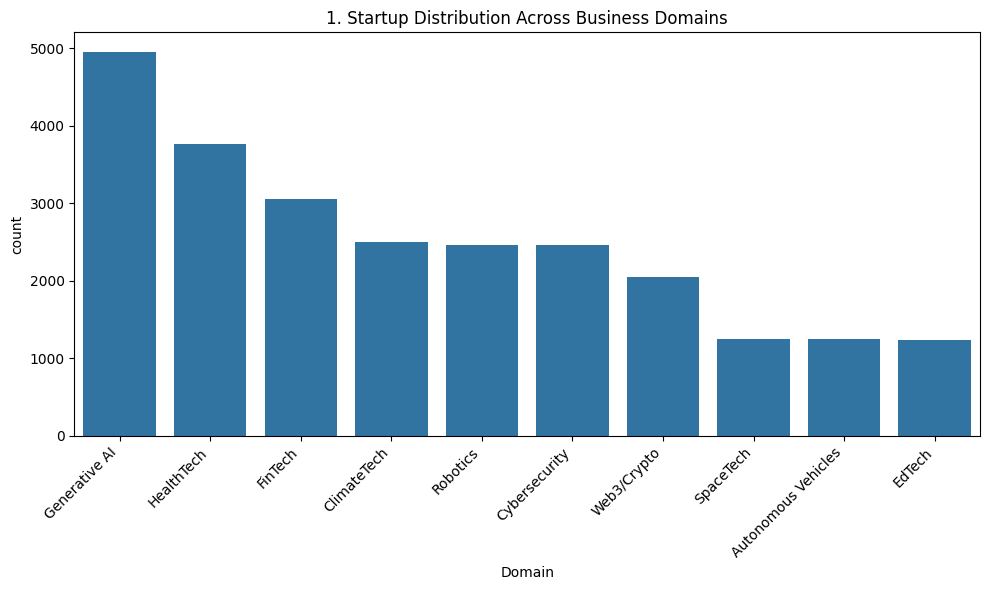

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Domain', order=df['Domain'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title(f'{plot_no}. Startup Distribution Across Business Domains')
show_fig()
plot_no += 1

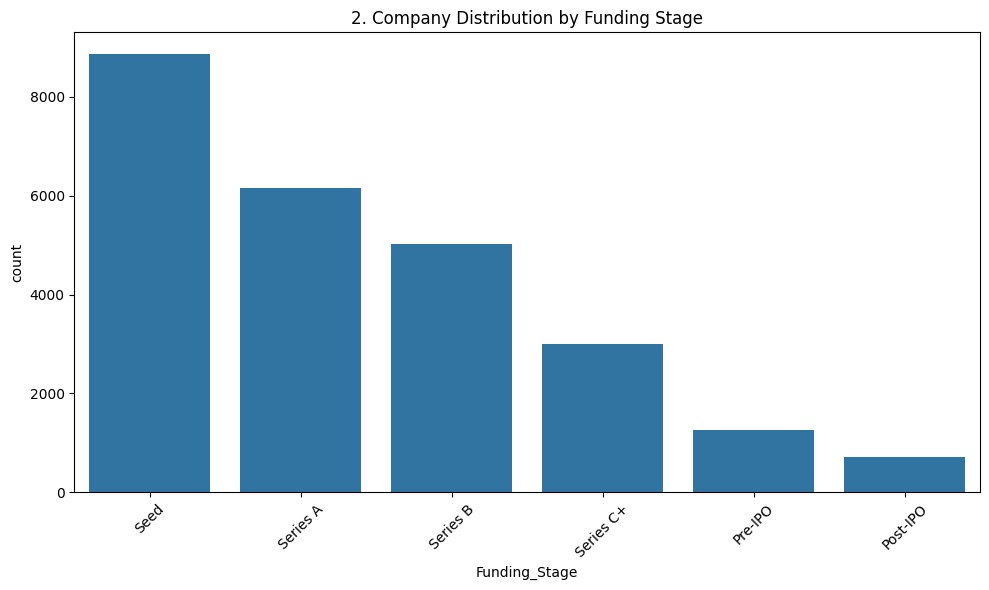

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Funding_Stage', order=df['Funding_Stage'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Company Distribution by Funding Stage')
show_fig()
plot_no += 1

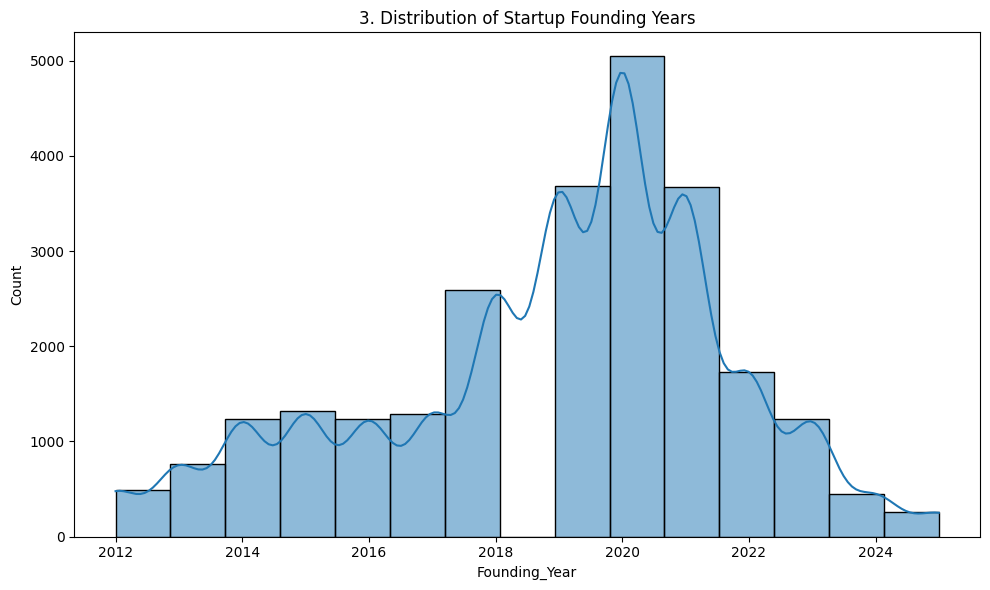

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Founding_Year'], bins=15, kde=True)
plt.title(f'{plot_no}. Distribution of Startup Founding Years')
show_fig()
plot_no += 1

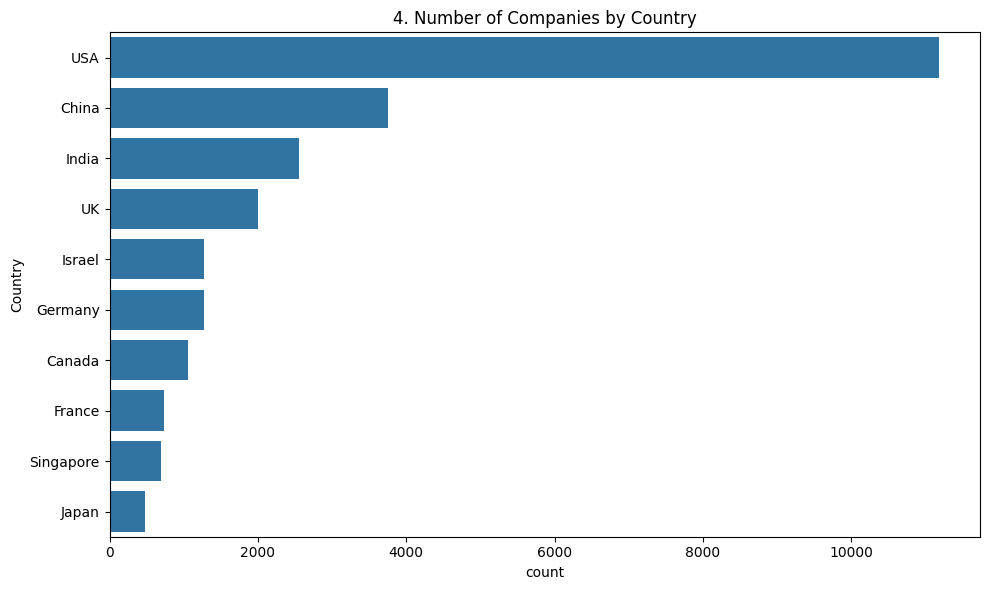

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Country', order=df['Country'].value_counts().index)
plt.title(f'{plot_no}. Number of Companies by Country')
show_fig()
plot_no += 1

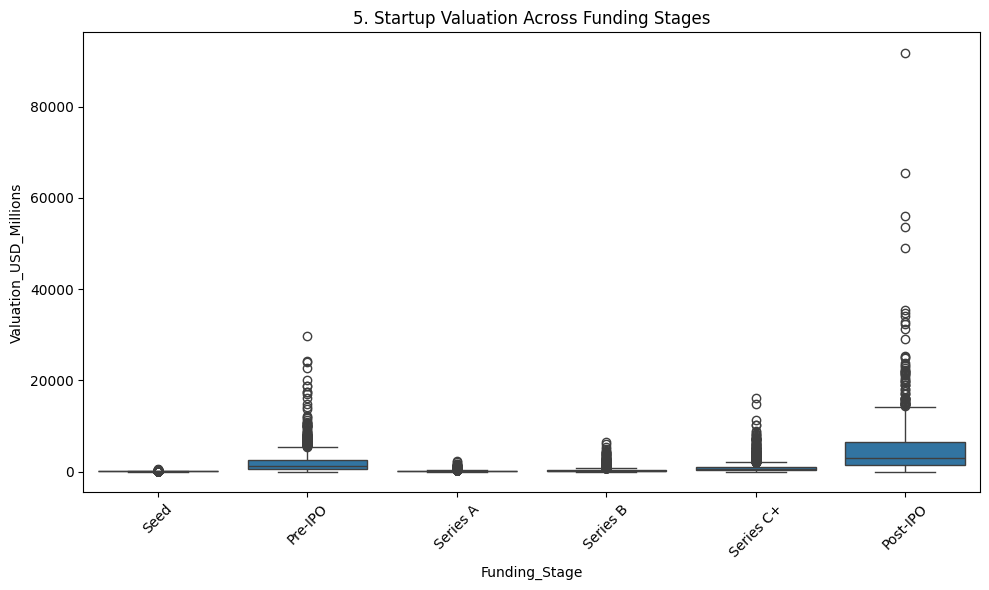

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Funding_Stage', y='Valuation_USD_Millions')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Startup Valuation Across Funding Stages')
show_fig()
plot_no += 1

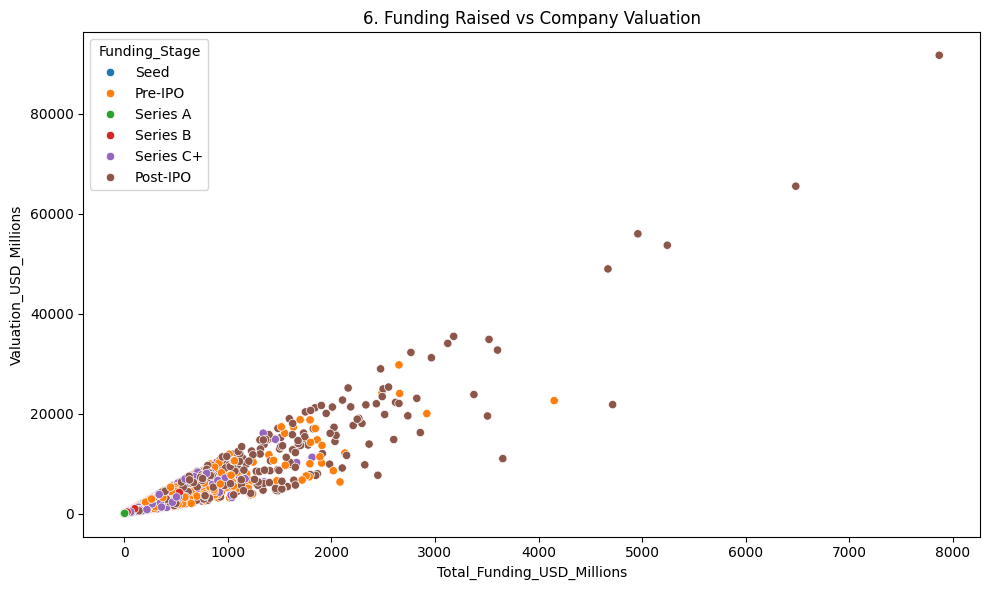

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Total_Funding_USD_Millions', y='Valuation_USD_Millions', hue='Funding_Stage')
plt.title(f'{plot_no}. Funding Raised vs Company Valuation')
show_fig()
plot_no += 1

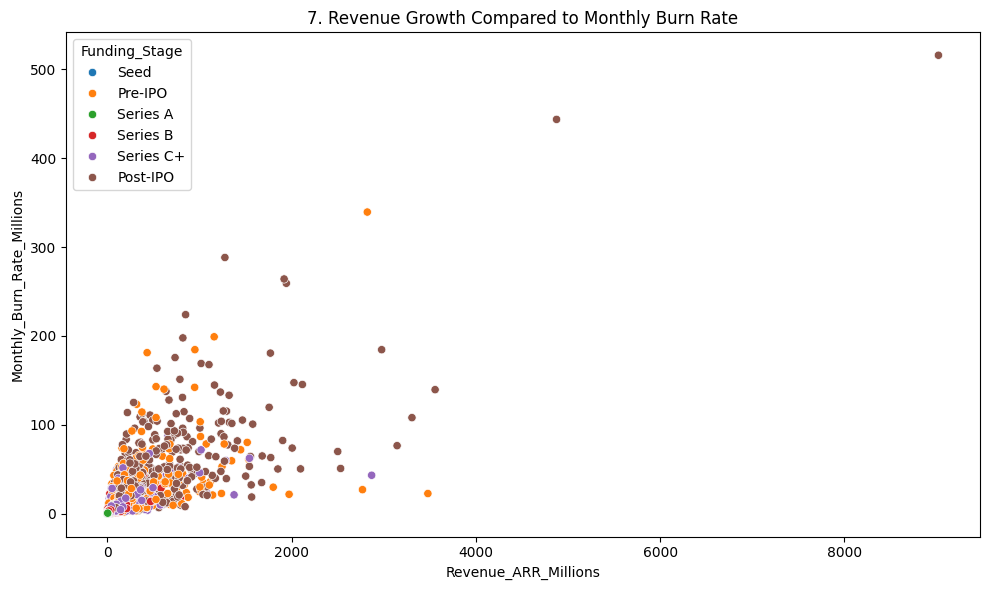

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Revenue_ARR_Millions', y='Monthly_Burn_Rate_Millions', hue='Funding_Stage')
plt.title(f'{plot_no}. Revenue Growth Compared to Monthly Burn Rate')
show_fig()
plot_no += 1

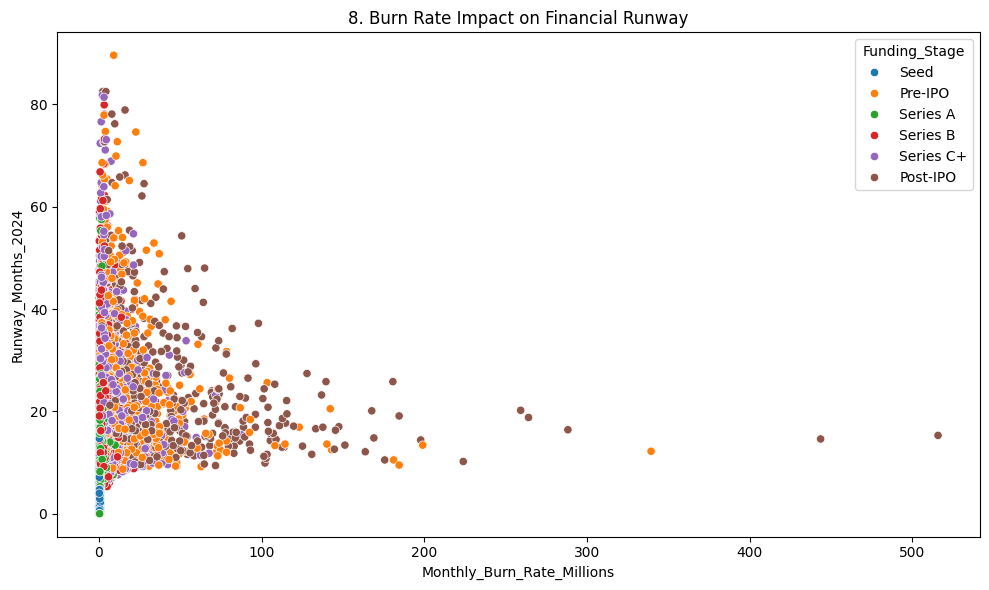

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Monthly_Burn_Rate_Millions', y='Runway_Months_2024', hue='Funding_Stage')
plt.title(f'{plot_no}. Burn Rate Impact on Financial Runway')
show_fig()
plot_no += 1

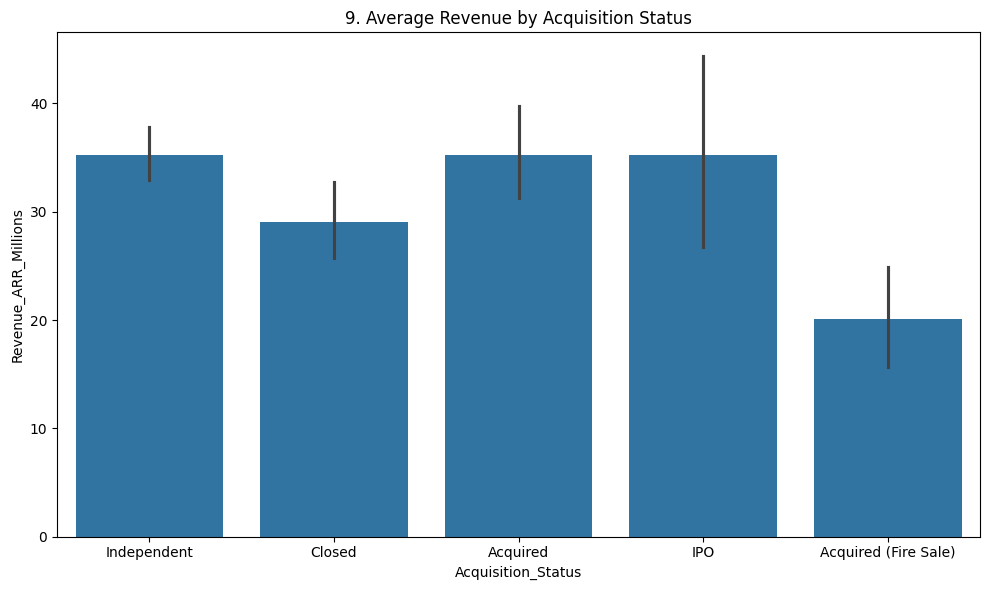

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Acquisition_Status', y='Revenue_ARR_Millions', estimator='mean')
plt.title(f'{plot_no}. Average Revenue by Acquisition Status')
show_fig()
plot_no += 1

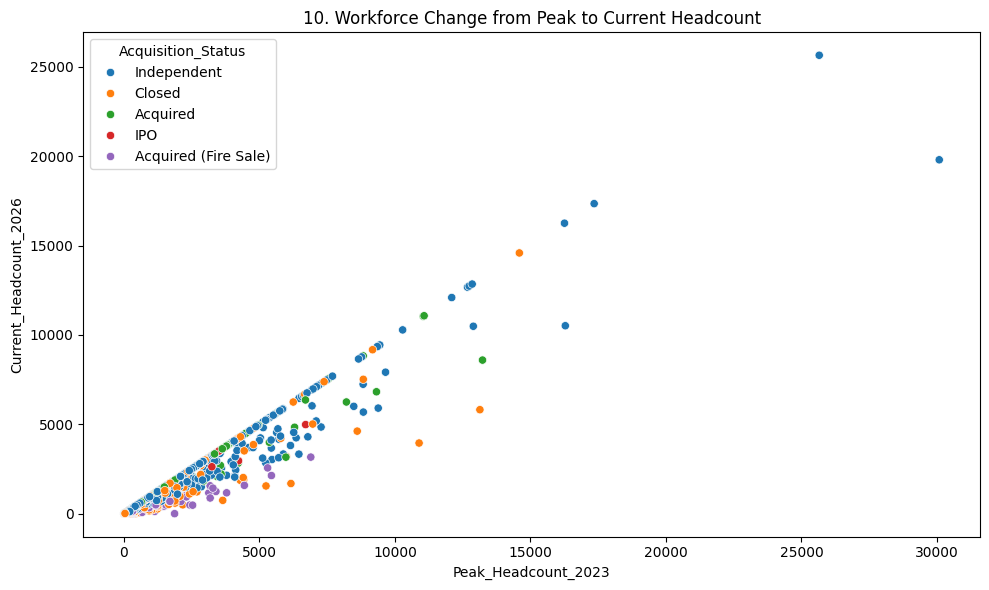

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Peak_Headcount_2023', y='Current_Headcount_2026', hue='Acquisition_Status')
plt.title(f'{plot_no}. Workforce Change from Peak to Current Headcount')
show_fig()
plot_no += 1

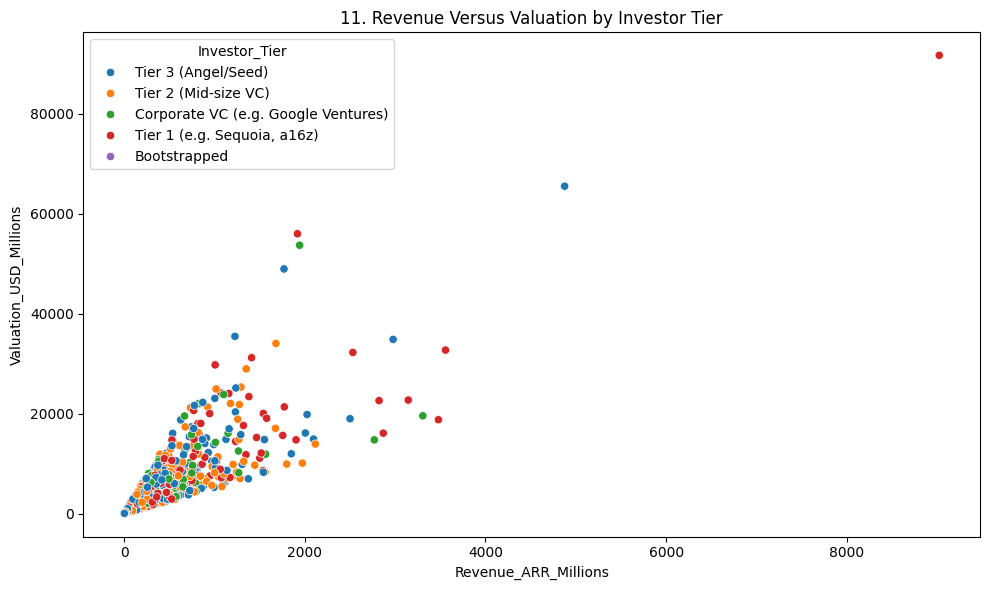

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Revenue_ARR_Millions', y='Valuation_USD_Millions', hue='Investor_Tier')
plt.title(f'{plot_no}. Revenue Versus Valuation by Investor Tier')
show_fig()
plot_no += 1

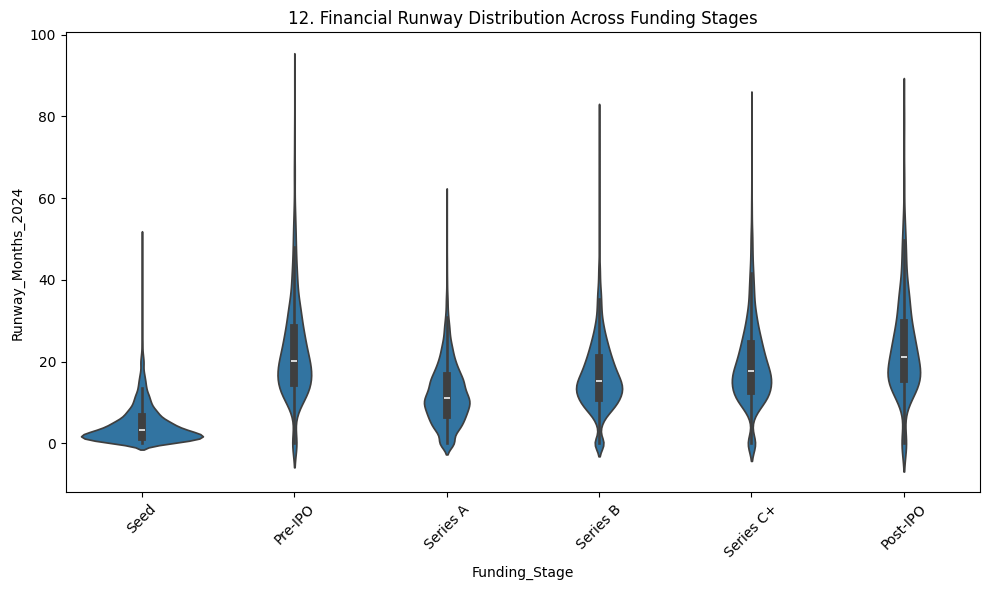

In [25]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Funding_Stage', y='Runway_Months_2024')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Financial Runway Distribution Across Funding Stages')
show_fig()
plot_no += 1

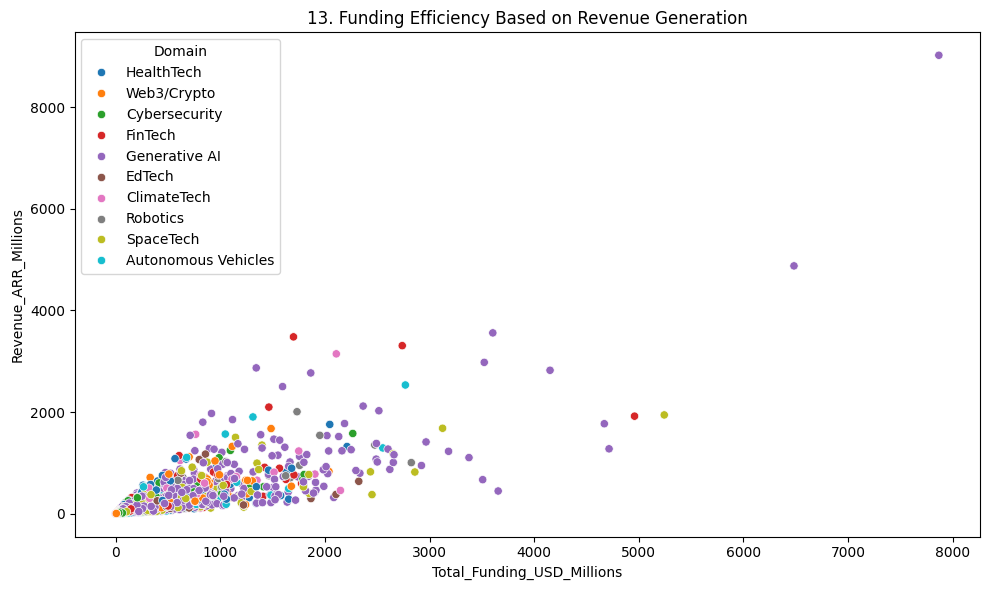

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Total_Funding_USD_Millions', y='Revenue_ARR_Millions', hue='Domain')
plt.title(f'{plot_no}. Funding Efficiency Based on Revenue Generation')
show_fig()
plot_no += 1

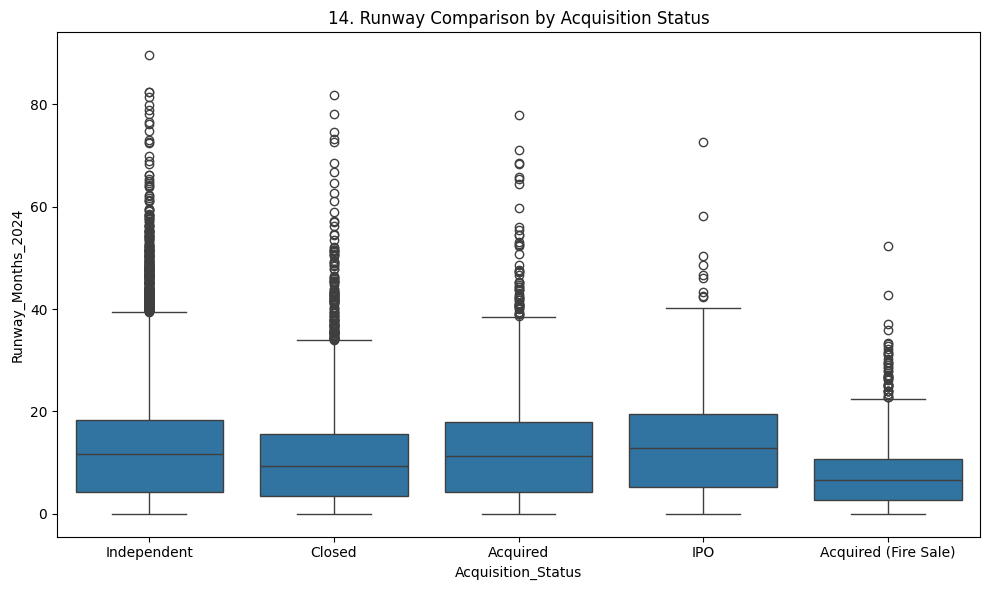

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Acquisition_Status', y='Runway_Months_2024')
plt.title(f'{plot_no}. Runway Comparison by Acquisition Status')
show_fig()
plot_no += 1

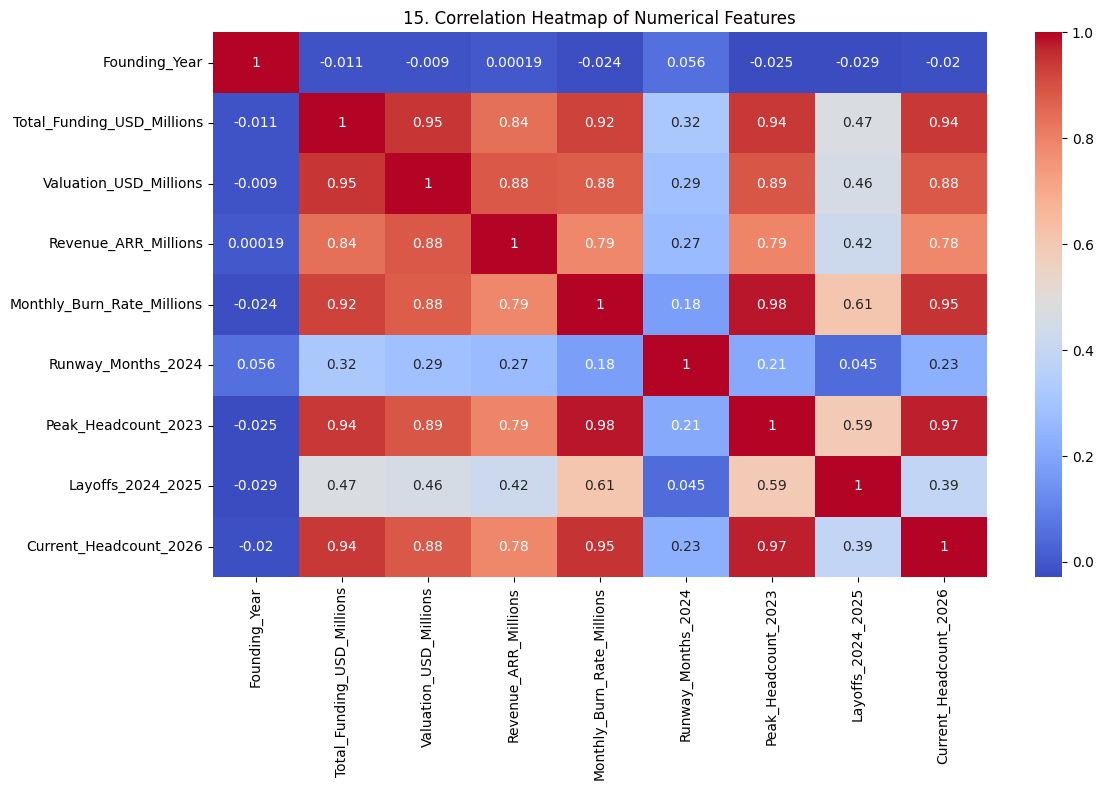

In [28]:
fig = plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Select target column

In [29]:
target = "Funding_Stage"

## Create features and target

In [30]:
X = df.drop(columns=[target])
y = df[target]

## Separate numerical and categorical columns

In [31]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

## Numerical preprocessing

In [32]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## Categorical preprocessing

In [33]:
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## Combine preprocessing

In [34]:
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

## Split dataset

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Build SVM classification pipeline

In [36]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", C=5, gamma="scale"))
])

## Train model

In [37]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict on test data

In [38]:
y_pred = model.predict(X_test)

## Print accuracy

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2%}")

Accuracy Score: 62.04%


## Print classification report

In [40]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

    Post-IPO       0.56      0.53      0.54       144
     Pre-IPO       0.39      0.26      0.31       251
        Seed       0.79      0.86      0.83      1772
    Series A       0.55      0.59      0.57      1231
    Series B       0.51      0.50      0.50      1003
   Series C+       0.44      0.36      0.39       599

    accuracy                           0.62      5000
   macro avg       0.54      0.52      0.52      5000
weighted avg       0.61      0.62      0.61      5000



## Plot confusion matrix

<Figure size 1000x800 with 0 Axes>

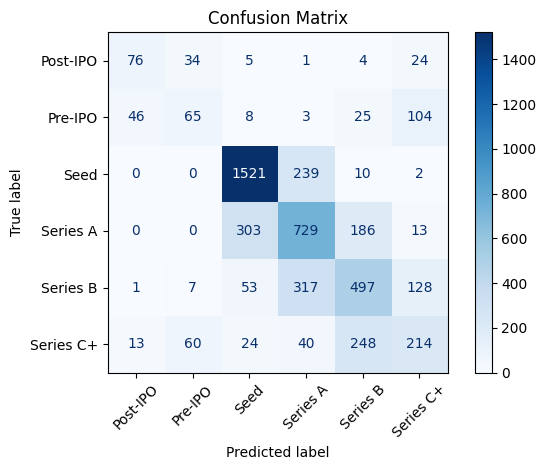

In [41]:
plt.figure(figsize=(10,8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()